TASK 1: CLASSIFICATION - STROKE PREDICTION

1. Loading Dataset...

2. Basic Dataset Information:
Shape: (5110, 12)

Data Types:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

3. Checking for Missing Values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

4. Checking for Duplicates:
Number of duplicate rows: 0

5. Sample Data:
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0

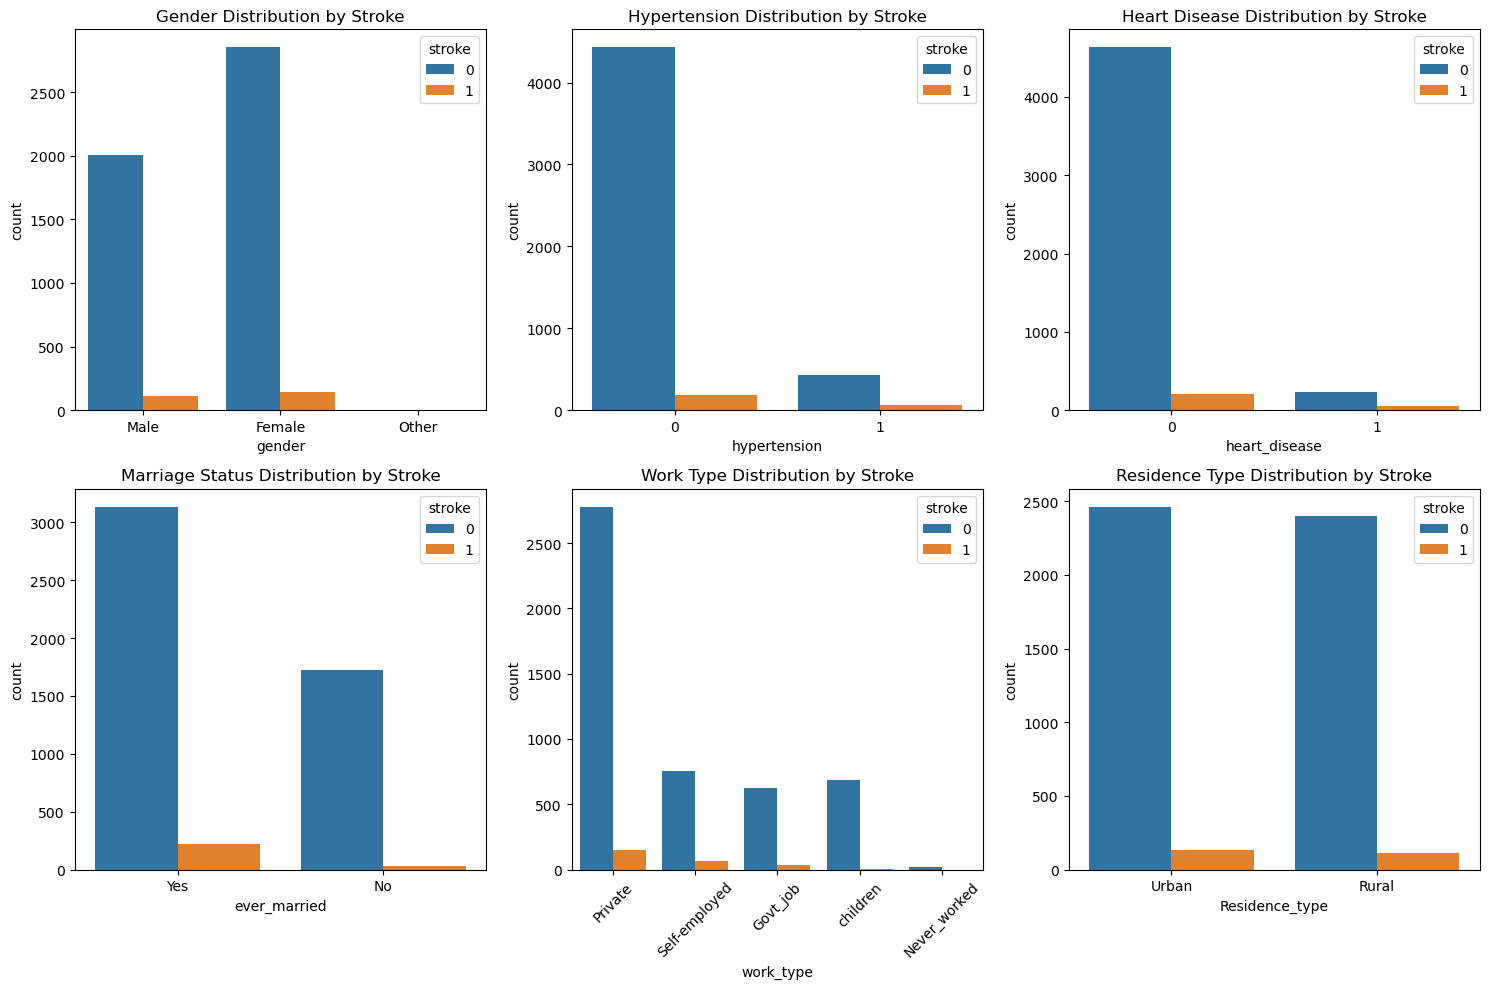

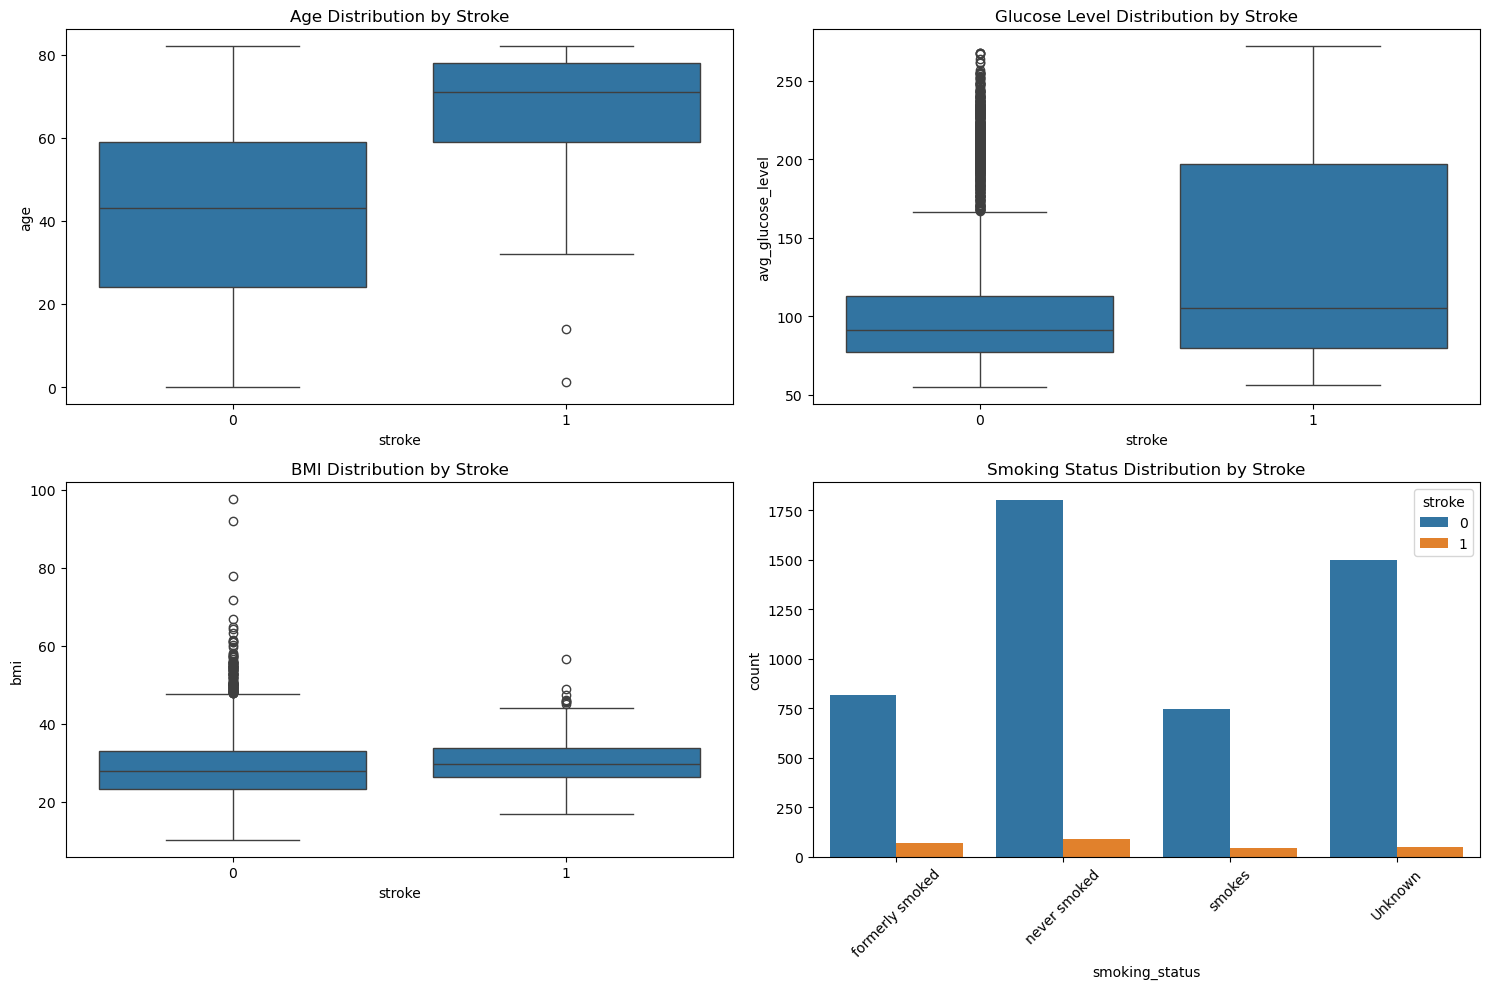

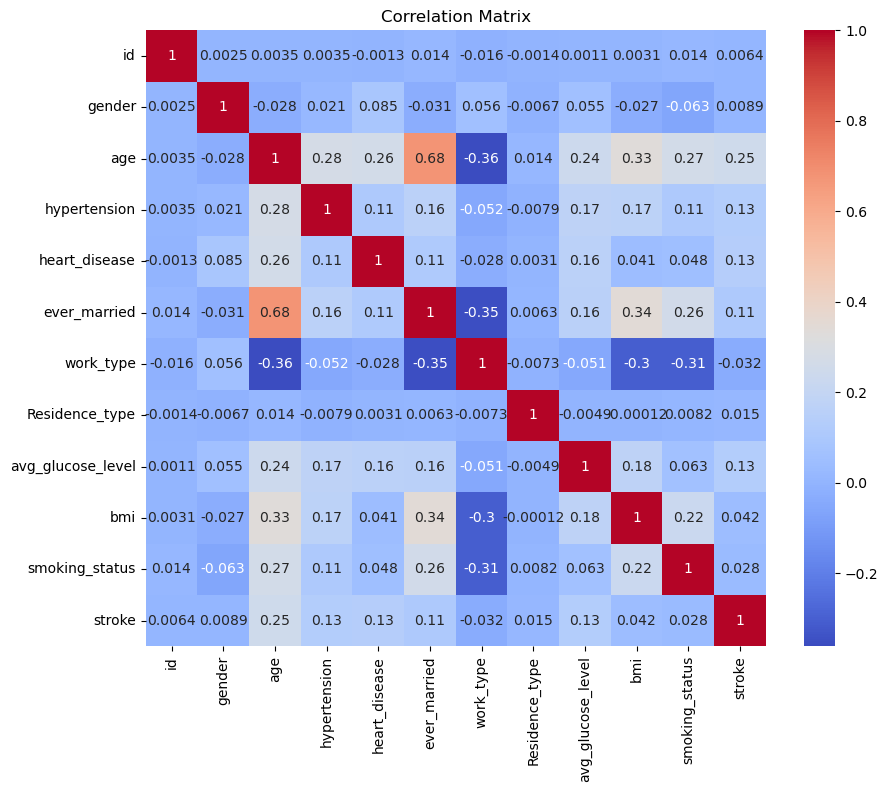

In [2]:
# Student: 371506 - Nina Nguyen
# Content: Task 1 Classification (Stroke Prediction)
# Dataset: D2 - healthcare-dataset-stroke-data

# Step 1: Loading Data, Data Pre-processing, EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

print("="*50)
print("TASK 1: CLASSIFICATION - STROKE PREDICTION")
print("="*50)

# load the dataset
print("\n1. Loading Dataset...")
df = pd.read_csv('.\Datasets\D2\healthcare-dataset-stroke-data.csv')

# display basic information
print("\n2. Basic Dataset Information:")
print(f"Shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)

# check for missing values and duplicates
print("\n3. Checking for Missing Values:")
print(df.isnull().sum())

print("\n4. Checking for Duplicates:")
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("Removing duplicate rows...")
    df = df.drop_duplicates(inplace=True)

# sample data
print("\n5. Sample Data:")
print(df.head())

# check class distribution
print("\n6. Class Distribution (Target Variable):")
print(df['stroke'].value_counts())
print(f"Percentage of stroke cases: {df['stroke'].mean() * 100:.2f}%")

# EDA
print("\n7. Performing Exploratory Data Analysis (EDA)...")

# create a directory for EDA figures if it doesnt exist
import os
if not os.path.exists('eda_figures'):
    os.makedirs('eda_figures')

# Figure 1: Distribution of categorical variables by stroke
plt.figure(figsize=(15, 10))

# gender =
plt.subplot(2, 3, 1)
sns.countplot(x='gender', hue='stroke', data=df)
plt.title('Gender Distribution by Stroke')

# hypertension 
plt.subplot(2, 3, 2)
sns.countplot(x='hypertension', hue='stroke', data=df)
plt.title('Hypertension Distribution by Stroke')

# heart disease
plt.subplot(2, 3, 3)
sns.countplot(x='heart_disease', hue='stroke', data=df)
plt.title('Heart Disease Distribution by Stroke')

# ever married
plt.subplot(2, 3, 4)
sns.countplot(x='ever_married', hue='stroke', data=df)
plt.title('Marriage Status Distribution by Stroke')

# work type 
plt.subplot(2, 3, 5)
sns.countplot(x='work_type', hue='stroke', data=df)
plt.xticks(rotation=45)
plt.title('Work Type Distribution by Stroke')

# Residence type 
plt.subplot(2, 3, 6)
sns.countplot(x='Residence_type', hue='stroke', data=df)
plt.title('Residence Type Distribution by Stroke')

plt.tight_layout()
plt.savefig('eda_figures/stroke_categorical_analysis.png')

# Figure 2: Distribution of numerical variables by stroke
plt.figure(figsize=(15, 10))

# age 
plt.subplot(2, 2, 1)
sns.boxplot(x='stroke', y='age', data=df)
plt.title('Age Distribution by Stroke')

# glucose level
plt.subplot(2, 2, 2)
sns.boxplot(x='stroke', y='avg_glucose_level', data=df)
plt.title('Glucose Level Distribution by Stroke')

# BMI 
plt.subplot(2, 2, 3)
sns.boxplot(x='stroke', y='bmi', data=df)
plt.title('BMI Distribution by Stroke')

# smoking status 
plt.subplot(2, 2, 4)
sns.countplot(x='smoking_status', hue='stroke', data=df)
plt.xticks(rotation=45)
plt.title('Smoking Status Distribution by Stroke')

plt.tight_layout()
plt.savefig('eda_figures/stroke_numerical_analysis.png')

# Figure 3: Correlation matrix for numerical features
plt.figure(figsize=(10, 8))
# create a copy of the dataframe with encoded categorical variables for correlation analysis
df_corr = df.copy()
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
for col in categorical_cols:
    le = LabelEncoder()
    df_corr[col] = le.fit_transform(df_corr[col])

# calculate correlation matrix
correlation = df_corr.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig('eda_figures/stroke_correlation.png')

print("EDA plots saved to 'eda_figures' directory")

In [3]:
# Step 2: Feature Engineering, Creating Train, and Test Datasets
print("\n8. Performing Data Preprocessing and Feature Engineering...")

# check for missing values 
print("Missing values in 'bmi' column:", df['bmi'].isnull().sum())

# handle missing values 
print("Handling missing values...")
# check if 'bmi' has missing values
if df['bmi'].isnull().sum() > 0:
    # using SimpleImputer to fill missing BMI values with median
    imputer = SimpleImputer(strategy='median')
    df['bmi'] = imputer.fit_transform(df[['bmi']])

# verify missing values
print(df.isnull().sum())

# drop the 'id' column as it's not relevant for prediction
df = df.drop('id', axis=1)

# handle categorical variables using one-hot encoding 
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# using get_dummies
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Shape after one-hot encoding:", df_encoded.shape)

# split features and target
X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']

# split data into training and testing sets
print("\n9. Splitting data into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# scale numerical features
print("10. Scaling numerical features...")
numerical_cols = ['age', 'avg_glucose_level', 'bmi']
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


8. Performing Data Preprocessing and Feature Engineering...
Missing values in 'bmi' column: 201
Handling missing values...
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64
Shape after one-hot encoding: (5110, 17)

9. Splitting data into training and testing sets...
10. Scaling numerical features...
Training data shape: (4088, 16)
Testing data shape: (1022, 16)


In [ ]:
# Step 3: Apply at least 2 algorithms for classification (Training and Testing)
print("\n11. Training Classification Models")

# algorithm 1: Logistic Regression
print("\nTraining Logistic Regression")
# using class_weight='balanced' due to class imbalance
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

# algorithm 2: Random Forest
print("Training Random Forest")
# using class_weight='balanced' due to class imbalance
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]


11. Training Classification Models...

Training Logistic Regression...
Training Random Forest...



12. Evaluating classification models...

Logistic Regression Evaluation:
Accuracy: 0.7446
Precision: 0.1375
Recall: 0.8000
F1 Score: 0.2346
AUC-ROC: 0.8436

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.82      1022


Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0          721          251
Actual 1           10           40

Random Forest Evaluation:
Accuracy: 0.9501
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
AUC-ROC: 0.7967

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg    

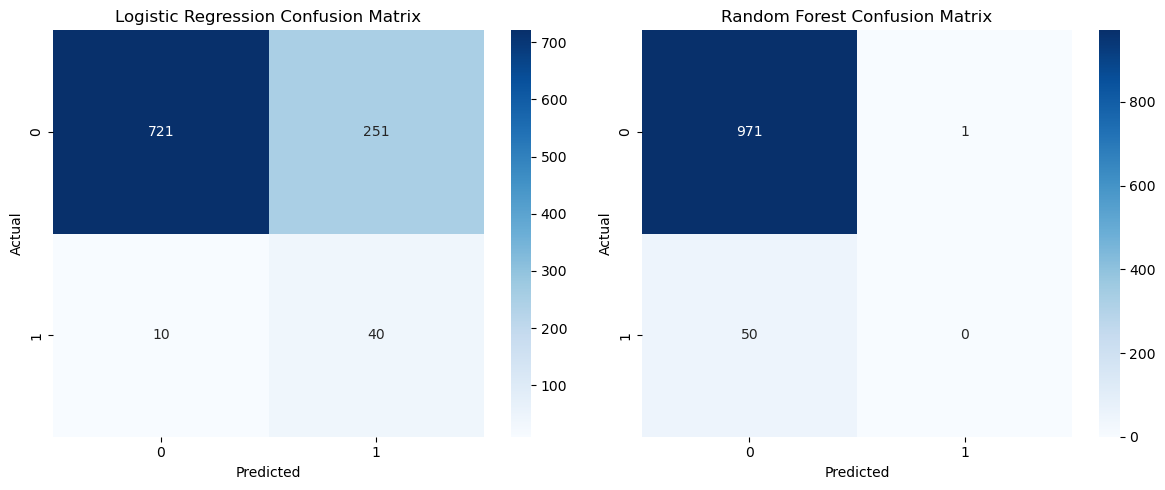

In [5]:
# Step 4: Generate at least 2 Evaluation Metrics on each algorithm
print("\n12. Evaluating classification models...")

# evaluation metrics for Logistic Regression
print("\nLogistic Regression Evaluation:")
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

print(f"Accuracy: {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall: {lr_recall:.4f}")
print(f"F1 Score: {lr_f1:.4f}")
print(f"AUC-ROC: {lr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix:")
lr_cm = confusion_matrix(y_test, lr_pred)
print(pd.DataFrame(lr_cm, columns=["Predicted 0", "Predicted 1"], index=["Actual 0", "Actual 1"]))

# evaluation metrics for Random Forest
print("\nRandom Forest Evaluation:")
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1 Score: {rf_f1:.4f}")
print(f"AUC-ROC: {rf_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
rf_cm = confusion_matrix(y_test, rf_pred)
print(pd.DataFrame(rf_cm, columns=["Predicted 0", "Predicted 1"], index=["Actual 0", "Actual 1"]))

# visualize confusion matrices
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 2, 2)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.savefig('eda_figures/stroke_confusion_matrices.png')


13. Comparing model results...
                 Model  Accuracy  Precision  Recall  F1 Score   AUC-ROC
0  Logistic Regression  0.744618   0.137457     0.8  0.234604  0.843642
1        Random Forest  0.950098   0.000000     0.0  0.000000  0.796667

Best model based on F1 score: Logistic Regression


<Figure size 1000x600 with 0 Axes>

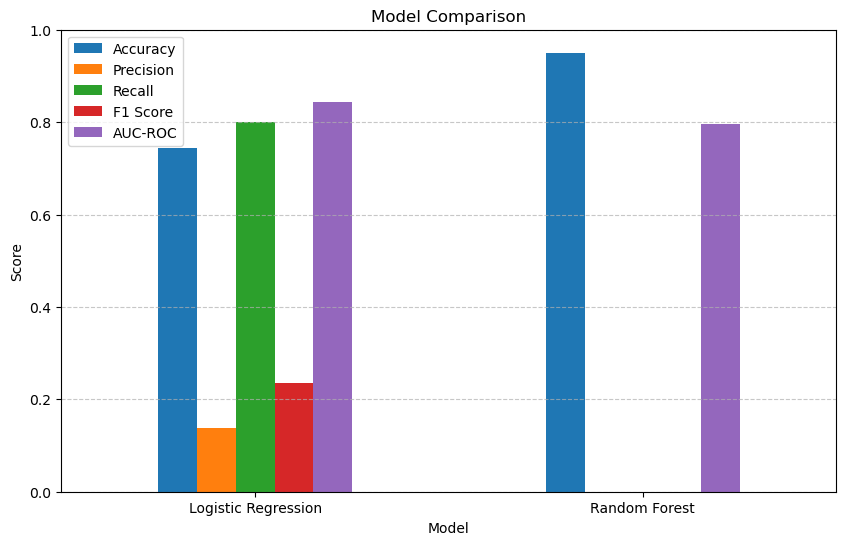

In [6]:
# Step 5: Comparing the results
print("\n13. Comparing model results...")

# create a comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, rf_accuracy],
    'Precision': [lr_precision, rf_precision],
    'Recall': [lr_recall, rf_recall],
    'F1 Score': [lr_f1, rf_f1],
    'AUC-ROC': [lr_auc, rf_auc]
})

print(comparison_df)

# visualize model comparison
plt.figure(figsize=(10, 6))
comparison_df.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('eda_figures/stroke_model_comparison.png')

# determine best model based on F1 score (since data is imbalanced)
best_model = 'Logistic Regression' if lr_f1 > rf_f1 else 'Random Forest'
print(f"\nBest model based on F1 score: {best_model}")


14. Fine-tuning the best model...
Fine-tuning Logistic Regression...
Best parameters: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}
Best F1 score: 0.23578710503723715

Tuned Logistic Regression Evaluation:
Accuracy: 0.7446
Precision: 0.1375
Recall: 0.8000
F1 Score: 0.2346
AUC-ROC: 0.8437

F1 Score Improvement: 0.00%

Top 10 Feature Coefficients:
                        Feature  Coefficient
0                           age     1.879101
11           work_type_children     0.908597
1                  hypertension     0.590901
15        smoking_status_smokes     0.323216
2                 heart_disease     0.228309
10      work_type_Self-employed     0.221671
3             avg_glucose_level     0.199341
14  smoking_status_never smoked     0.172800
7              ever_married_Yes     0.160057
8        work_type_Never_worked     0.154259

15. Task 1 (Classification) Summary:
--------------------------------------------------
Best Model: Tuned Logistic Regression
Best Parameters: {'C': 1, 'pena

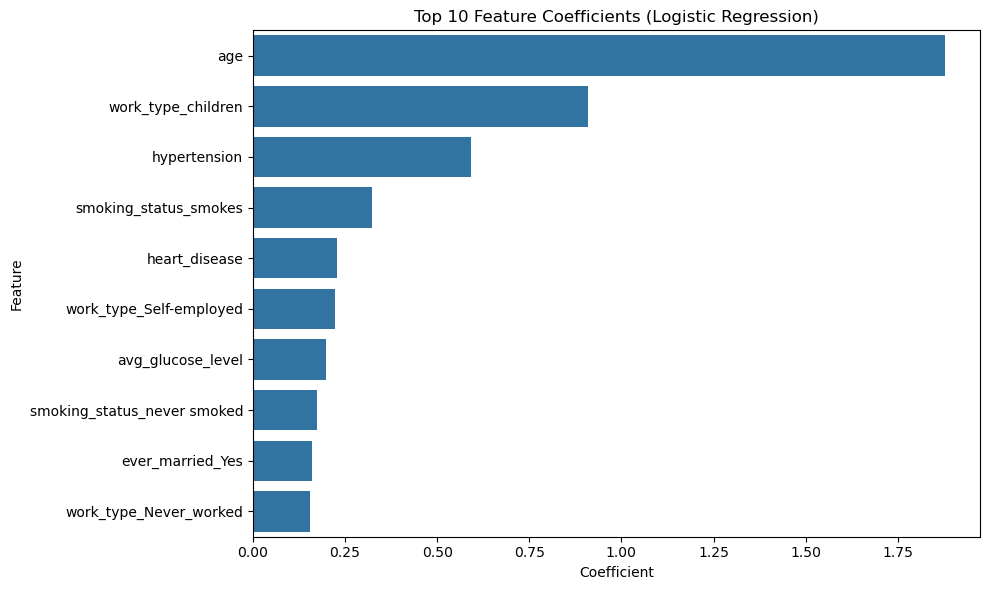

In [7]:
# Step 6: Fine Tune the best algorithm
print("\n14. Fine-tuning the best model...")

if best_model == 'Logistic Regression':
    # fine-tune Logistic Regression
    print("Fine-tuning Logistic Regression...")
    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'saga'],
        'penalty': ['l1', 'l2']
    }
    
    grid_search = GridSearchCV(
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    
    print("Best parameters:", grid_search.best_params_)
    print("Best F1 score:", grid_search.best_score_)
    
    # evaluate the tuned model
    tuned_lr = grid_search.best_estimator_
    tuned_lr_pred = tuned_lr.predict(X_test)
    tuned_lr_prob = tuned_lr.predict_proba(X_test)[:, 1]
    
    tuned_lr_accuracy = accuracy_score(y_test, tuned_lr_pred)
    tuned_lr_precision = precision_score(y_test, tuned_lr_pred)
    tuned_lr_recall = recall_score(y_test, tuned_lr_pred)
    tuned_lr_f1 = f1_score(y_test, tuned_lr_pred)
    tuned_lr_auc = roc_auc_score(y_test, tuned_lr_prob)
    
    print("\nTuned Logistic Regression Evaluation:")
    print(f"Accuracy: {tuned_lr_accuracy:.4f}")
    print(f"Precision: {tuned_lr_precision:.4f}")
    print(f"Recall: {tuned_lr_recall:.4f}")
    print(f"F1 Score: {tuned_lr_f1:.4f}")
    print(f"AUC-ROC: {tuned_lr_auc:.4f}")
    
    # improvement calculation
    f1_improvement = ((tuned_lr_f1 - lr_f1) / lr_f1) * 100
    print(f"\nF1 Score Improvement: {f1_improvement:.2f}%")
    
    # feature importance for Logistic Regression
    feature_importances = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': np.abs(tuned_lr.coef_[0])
    })
    feature_importances = feature_importances.sort_values('Coefficient', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Coefficient', y='Feature', data=feature_importances.head(10))
    plt.title('Top 10 Feature Coefficients (Logistic Regression)')
    plt.tight_layout()
    plt.savefig('eda_figures/stroke_feature_coefficients.png')
    
    print("\nTop 10 Feature Coefficients:")
    print(feature_importances.head(10))
    
else:
    # fine-tune Random Forest
    print("Fine-tuning Random Forest...")
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    grid_search = GridSearchCV(
        RandomForestClassifier(class_weight='balanced', random_state=42),
        param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    
    print("Best parameters:", grid_search.best_params_)
    print("Best F1 score:", grid_search.best_score_)
    
    # evaluate the tuned model
    tuned_rf = grid_search.best_estimator_
    tuned_rf_pred = tuned_rf.predict(X_test)
    tuned_rf_prob = tuned_rf.predict_proba(X_test)[:, 1]
    
    tuned_rf_accuracy = accuracy_score(y_test, tuned_rf_pred)
    tuned_rf_precision = precision_score(y_test, tuned_rf_pred)
    tuned_rf_recall = recall_score(y_test, tuned_rf_pred)
    tuned_rf_f1 = f1_score(y_test, tuned_rf_pred)
    tuned_rf_auc = roc_auc_score(y_test, tuned_rf_prob)
    
    print("\nTuned Random Forest Evaluation:")
    print(f"Accuracy: {tuned_rf_accuracy:.4f}")
    print(f"Precision: {tuned_rf_precision:.4f}")
    print(f"Recall: {tuned_rf_recall:.4f}")
    print(f"F1 Score: {tuned_rf_f1:.4f}")
    print(f"AUC-ROC: {tuned_rf_auc:.4f}")
    
    # improvement calculation
    f1_improvement = ((tuned_rf_f1 - rf_f1) / rf_f1) * 100
    print(f"\nF1 Score Improvement: {f1_improvement:.2f}%")
    
    # feature importance for Random Forest
    feature_importances = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': tuned_rf.feature_importances_
    })
    feature_importances = feature_importances.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10))
    plt.title('Top 10 Feature Importances (Random Forest)')
    plt.tight_layout()
    plt.savefig('eda_figures/stroke_feature_importances.png')
    
    print("\nTop 10 Feature Importances:")
    print(feature_importances.head(10))

# summary
print("\n15. Task 1 (Classification) Summary:")
print("-" * 50)
if best_model == 'Logistic Regression':
    print(f"Best Model: Tuned Logistic Regression")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Final F1 Score: {tuned_lr_f1:.4f} (Improvement of {f1_improvement:.2f}%)")
    print(f"Final AUC-ROC: {tuned_lr_auc:.4f}")
else:
    print(f"Best Model: Tuned Random Forest")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Final F1 Score: {tuned_rf_f1:.4f} (Improvement of {f1_improvement:.2f}%)")
    print(f"Final AUC-ROC: {tuned_rf_auc:.4f}")

print("\nTop 3 Most Important Features:")
print(feature_importances.head(3))
print("-" * 50)

print("\nTask 1 (Classification) completed successfully!")